In [1]:
import os
import cv2
import numpy as np 
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
#check for gpu
import torch
print("CUDA avialable:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))
    
else:
    print("WARNING:CUDA GPU not available")

CUDA avialable: True
GPU: NVIDIA GeForce RTX 2050


In [3]:
# load the segmentation model
seg_model = YOLO("yolo11n-seg.pt")

print("YOLO11 segmentation model loaded.")

YOLO11 segmentation model loaded.


In [4]:
#select an image
IMAGE_PATH = r"C:\Users\SUYASH\OneDrive\Pictures\photo-1478098711619-5ab0b478d6e6.webp"

print("Image exists:", os.path.exists(IMAGE_PATH))
print("Image:", IMAGE_PATH)

Image exists: True
Image: C:\Users\SUYASH\OneDrive\Pictures\photo-1478098711619-5ab0b478d6e6.webp


In [5]:
#run segmentation
results = seg_model(
    IMAGE_PATH,
    conf=0.35,
    device=0,
    verbose=False
)

result = results[0]

print("Segmentation completed.")
print("Objects detected:", len(result.boxes))

Segmentation completed.
Objects detected: 1


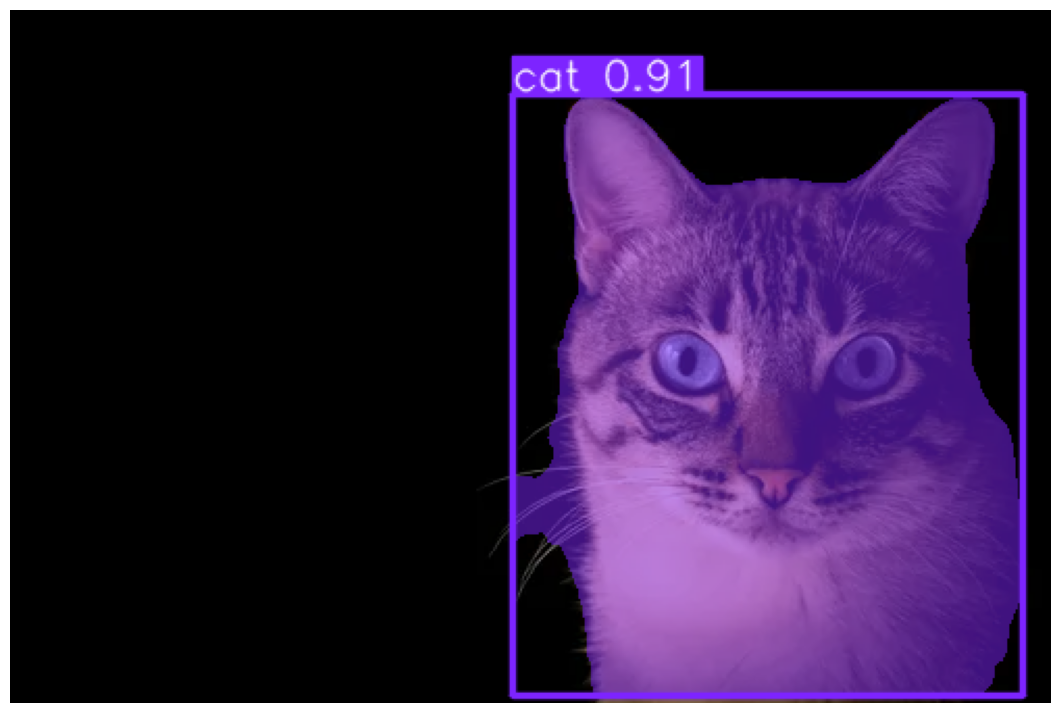

In [6]:
#Display segmentation result
annotated = result.plot()

plt.figure(figsize=(14, 9))

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

In [7]:
# check whether masks exist
print("Boxes:", len(result.boxes))

if result.masks is not None:
    print("Masks:", len(result.masks))
    print("Mask shape:", result.masks.data.shape)
else:
    print("No masks detected.")

Boxes: 1
Masks: 1
Mask shape: torch.Size([1, 448, 640])


In [8]:
#print detected objects
for i, box in enumerate(result.boxes):

    class_id = int(box.cls.item())
    confidence = float(box.conf.item())

    class_name = result.names[class_id]

    print(
        f"{i}: {class_name:20s} "
        f"confidence={confidence:.3f}"
    )

0: cat                  confidence=0.905


In [9]:
# extract one mask
mask_index = 0

mask = result.masks.data[
    mask_index
].cpu().numpy()

print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

Mask shape: (448, 640)
Mask values: [0 1]


In [10]:
# resize mask to original image size
image = cv2.imread(IMAGE_PATH)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

height, width = image.shape[:2]

mask_resized = cv2.resize(
    mask,
    (width, height),
    interpolation=cv2.INTER_NEAREST
)

binary_mask = mask_resized > 0.5

print("Image:", image.shape)
print("Mask :", binary_mask.shape)

Image: (333, 500, 3)
Mask : (333, 500)


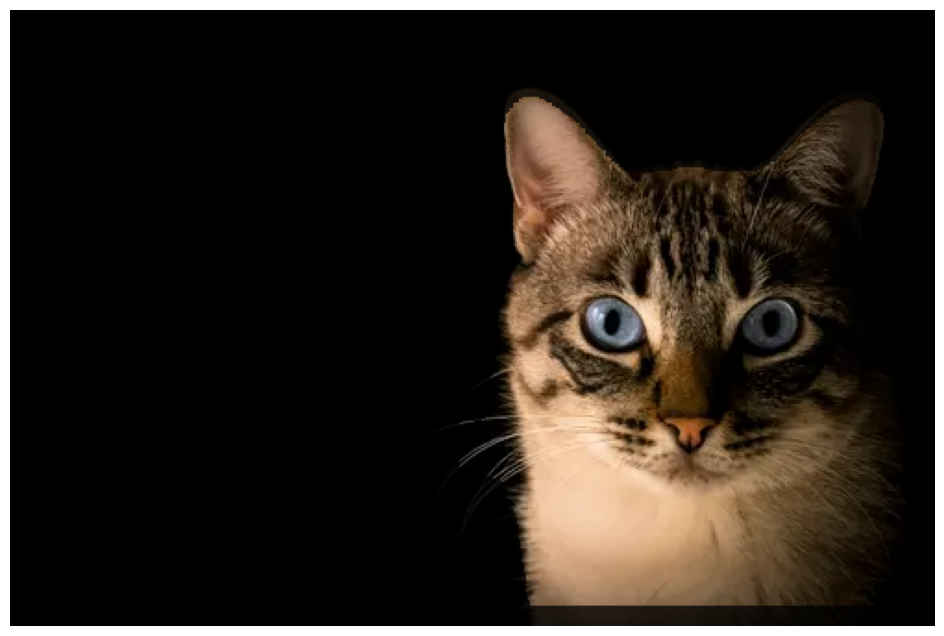

In [11]:
#First real editing operation
highlighted = image_rgb.copy()

highlighted[~binary_mask] = (
    highlighted[~binary_mask] * 0.25
).astype(np.uint8)

plt.figure(figsize=(12, 8))
plt.imshow(highlighted)
plt.axis("off")
plt.show()

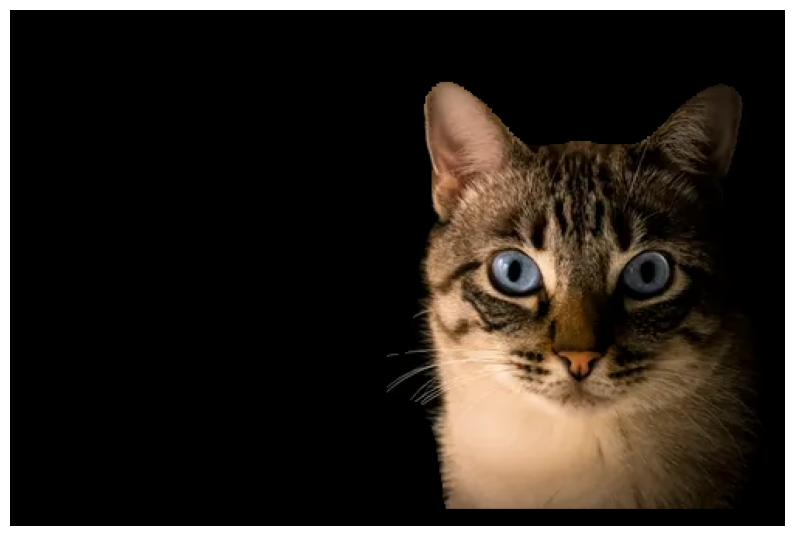

In [12]:
#extract the object
object_only = np.zeros_like(image_rgb)

object_only[binary_mask] = image_rgb[binary_mask]

plt.figure(figsize=(10, 8))
plt.imshow(object_only)
plt.axis("off")
plt.show()

In [13]:
#create transparent png
rgba = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2BGRA
)

rgba[:, :, 3] = (
    binary_mask.astype(np.uint8) * 255
)

transparent_output = "extracted_object.png"

cv2.imwrite(
    transparent_output,
    rgba
)

print("Saved:", transparent_output)

Saved: extracted_object.png


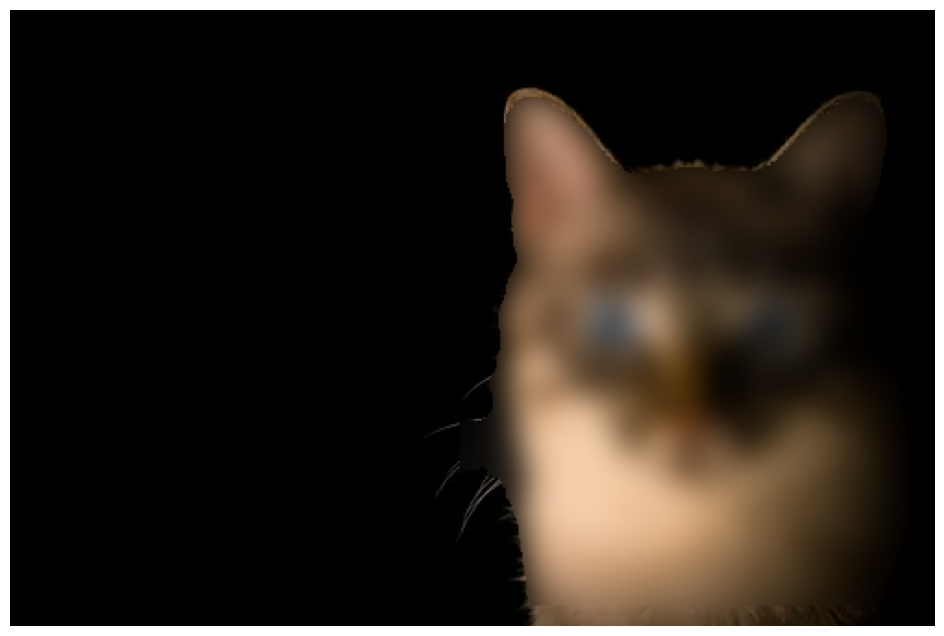

In [14]:
# blur only the selected object
blurred = image.copy()

roi_blurred = cv2.GaussianBlur(
    image,
    (51, 51),
    0
)

blurred[binary_mask] = roi_blurred[binary_mask]

plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(
        blurred,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

In [15]:
#save blurred image
blur_output = "blurred_object.jpg"

cv2.imwrite(
    blur_output,
    blurred
)

print("Saved:", blur_output)

Saved: blurred_object.jpg


In [16]:
# create object selection function
def get_detected_objects(result):
    
    objects = []

    for i, box in enumerate(result.boxes):

        class_id = int(box.cls.item())
        confidence = float(box.conf.item())

        objects.append({
            "index": i,
            "class_id": class_id,
            "class_name": result.names[class_id],
            "confidence": confidence
        })

    return objects


objects = get_detected_objects(result)

for obj in objects:
    print(obj)

{'index': 0, 'class_id': 15, 'class_name': 'cat', 'confidence': 0.9054219126701355}


In [17]:
#select object by class
def select_objects(
    objects,
    class_name,
    min_confidence=0.35
):
    
    return [
        obj
        for obj in objects
        if (
            obj["class_name"] == class_name
            and obj["confidence"] >= min_confidence
        )
    ]


selected = select_objects(
    objects,
    class_name="person"
)

print("Selected objects:")

for obj in selected:
    print(obj)

Selected objects:


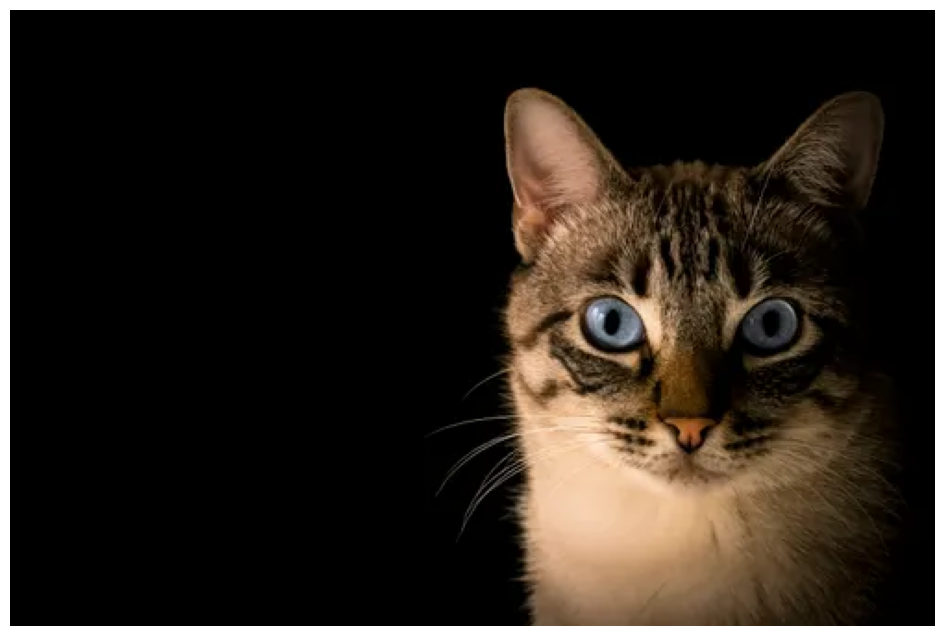

In [18]:
#blur all objects of a chosen class
def blur_class(
    image_path,
    result,
    class_name,
    confidence=0.35
):

    image = cv2.imread(image_path)

    selected_indices = []

    for i, box in enumerate(result.boxes):

        class_id = int(box.cls.item())
        conf = float(box.conf.item())

        name = result.names[class_id]

        if (
            name == class_name
            and conf >= confidence
        ):
            selected_indices.append(i)

    if result.masks is None:
        return image

    for i in selected_indices:

        mask = (
            result.masks.data[i]
            .cpu()
            .numpy()
        )

        mask = cv2.resize(
            mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        mask = mask > 0.5

        blurred = cv2.GaussianBlur(
            image,
            (51, 51),
            0
        )

        image[mask] = blurred[mask]

    return image


blurred_people = blur_class(
    IMAGE_PATH,
    result,
    "person"
)

plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(
        blurred_people,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

In [19]:
#save the final class-based edit
output_path = "all_people_blurred.jpg"

cv2.imwrite(
    output_path,
    blurred_people
)

print("Saved:", output_path)

Saved: all_people_blurred.jpg


In [20]:
# create one rreusable segmenatation function
def detect_objects(image_path, confidence=0.35):
    
    results = seg_model(
        image_path,
        conf=confidence,
        device=0,
        verbose=False
    )

    return results[0]


result = detect_objects(
    IMAGE_PATH,
    confidence=0.35
)

print("Detection completed.")
print("Objects found:", len(result.boxes))

Detection completed.
Objects found: 1


In [21]:
# create a clean object list
def list_objects(result):
    
    objects = []

    for i, box in enumerate(result.boxes):
        
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())

        objects.append({
            "index": i,
            "class_id": class_id,
            "name": result.names[class_id],
            "confidence": confidence
        })

    return objects


objects = list_objects(result)

for obj in objects:
    print(
        f"[{obj['index']}] "
        f"{obj['name']} "
        f"confidence={obj['confidence']:.3f}"
    )

[0] cat confidence=0.905


In [22]:
# get a specific object mask
def get_object_mask(result, object_index):
    
    if result.masks is None:
        raise ValueError("No segmentation masks found.")

    if object_index >= len(result.masks.data):
        raise IndexError("Invalid object index.")

    mask = (
        result.masks.data[object_index]
        .cpu()
        .numpy()
    )

    image_height, image_width = result.orig_shape

    mask = cv2.resize(
        mask,
        (image_width, image_height),
        interpolation=cv2.INTER_NEAREST
    )

    return mask > 0.5

In [23]:
# extract object as transparent png
def extract_object(
    image_path,
    result,
    object_index,
    output_path="extracted_object.png"
):
    
    image = cv2.imread(image_path)

    mask = get_object_mask(
        result,
        object_index
    )

    rgba = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2BGRA
    )

    rgba[:, :, 3] = (
        mask.astype(np.uint8) * 255
    )

    cv2.imwrite(
        output_path,
        rgba
    )

    return output_path


output = extract_object(
    IMAGE_PATH,
    result,
    object_index=0,
    output_path="object_extracted.png"
)

print("Saved:", output)

Saved: object_extracted.png


In [24]:
# blur one object
def blur_object(
    image_path,
    result,
    object_index,
    output_path="object_blurred.jpg"
):
    
    image = cv2.imread(image_path)

    mask = get_object_mask(
        result,
        object_index
    )

    blurred = cv2.GaussianBlur(
        image,
        (51, 51),
        0
    )

    output = image.copy()

    output[mask] = blurred[mask]

    cv2.imwrite(
        output_path,
        output
    )

    return output_path


output = blur_object(
    IMAGE_PATH,
    result,
    object_index=0,
    output_path="object_blurred.jpg"
)

print("Saved:", output)

Saved: object_blurred.jpg


In [25]:
# highlight one object
def highlight_object(
    image_path,
    result,
    object_index,
    output_path="object_highlighted.jpg"
):
    
    image = cv2.imread(image_path)

    mask = get_object_mask(
        result,
        object_index
    )

    output = (
        image.astype(np.float32) * 0.25
    ).astype(np.uint8)

    output[mask] = image[mask]

    cv2.imwrite(
        output_path,
        output
    )

    return output_path


output = highlight_object(
    IMAGE_PATH,
    result,
    object_index=0,
    output_path="object_highlighted.jpg"
)

print("Saved:", output)

Saved: object_highlighted.jpg


In [26]:
# crop object using its segmentation mask
def crop_object(
    image_path,
    result,
    object_index,
    output_path="object_crop.png"
):
    
    image = cv2.imread(image_path)

    mask = get_object_mask(
        result,
        object_index
    )

    ys, xs = np.where(mask)

    if len(xs) == 0 or len(ys) == 0:
        raise ValueError("Object mask is empty.")

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    crop = image[
        y1:y2 + 1,
        x1:x2 + 1
    ]

    crop_mask = mask[
        y1:y2 + 1,
        x1:x2 + 1
    ]

    rgba = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2BGRA
    )

    rgba[:, :, 3] = (
        crop_mask.astype(np.uint8) * 255
    )

    cv2.imwrite(
        output_path,
        rgba
    )

    return output_path


output = crop_object(
    IMAGE_PATH,
    result,
    object_index=0,
    output_path="object_crop.png"
)

print("Saved:", output)

Saved: object_crop.png


In [27]:
# find objects by class name
def find_objects(
    result,
    class_name,
    min_confidence=0.35
):
    
    matches = []

    for i, box in enumerate(result.boxes):
        
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())

        name = result.names[class_id]

        if (
            name.lower() == class_name.lower()
            and confidence >= min_confidence
        ):
            matches.append(i)

    return matches


cat_objects = find_objects(
    result,
    "cat"
)

print("Cat object indices:", cat_objects)

Cat object indices: [0]


In [28]:
# extract by object name
def extract_class(
    image_path,
    result,
    class_name,
    min_confidence=0.35
):
    
    indices = find_objects(
        result,
        class_name,
        min_confidence
    )

    if len(indices) == 0:
        print(
            f"No '{class_name}' found."
        )
        return []

    outputs = []

    for number, index in enumerate(indices):

        output_path = (
            f"{class_name}_{number}.png"
        )

        extract_object(
            image_path,
            result,
            index,
            output_path
        )

        outputs.append(output_path)

    return outputs


outputs = extract_class(
    IMAGE_PATH,
    result,
    "cat"
)

print("Created:", outputs)

Created: ['cat_0.png']


In [29]:
# blur an entire class
def blur_class(
    image_path,
    result,
    class_name,
    min_confidence=0.35,
    output_path="blurred_class.jpg"
):
    
    image = cv2.imread(image_path)

    indices = find_objects(
        result,
        class_name,
        min_confidence
    )

    if len(indices) == 0:
        print(
            f"No '{class_name}' found."
        )
        return None

    output = image.copy()

    blurred = cv2.GaussianBlur(
        image,
        (51, 51),
        0
    )

    for index in indices:

        mask = get_object_mask(
            result,
            index
        )

        output[mask] = blurred[mask]

    cv2.imwrite(
        output_path,
        output
    )

    return output_path

In [30]:
# highlight a class
def highlight_class(
    image_path,
    result,
    class_name,
    min_confidence=0.35,
    output_path="highlighted_class.jpg"
):
    
    image = cv2.imread(image_path)

    indices = find_objects(
        result,
        class_name,
        min_confidence
    )

    if len(indices) == 0:
        print(
            f"No '{class_name}' found."
        )
        return None

    output = (
        image.astype(np.float32) * 0.20
    ).astype(np.uint8)

    for index in indices:

        mask = get_object_mask(
            result,
            index
        )

        output[mask] = image[mask]

    cv2.imwrite(
        output_path,
        output
    )

    return output_path

In [32]:
# create a single simple editor function
def edit_object(
    image_path,
    object_name,
    operation,
    confidence=0.35
):
    
    result = detect_objects(
        image_path,
        confidence
    )

    indices = find_objects(
        result,
        object_name,
        confidence
    )

    if len(indices) == 0:
        print(
            f"No '{object_name}' detected."
        )
        return None

    index = indices[0]

    if operation == "extract":

        return extract_object(
            image_path,
            result,
            index,
            f"{object_name}_extracted.png"
        )

    elif operation == "blur":

        return blur_object(
            image_path,
            result,
            index,
            f"{object_name}_blurred.jpg"
        )

    elif operation == "highlight":

        return highlight_object(
            image_path,
            result,
            index,
            f"{object_name}_highlighted.jpg"
        )

    elif operation == "crop":

        return crop_object(
            image_path,
            result,
            index,
            f"{object_name}_crop.png"
        )

    else:

        raise ValueError(
            "Operation must be: "
            "extract, blur, highlight, or crop"
        )

In [ ]:
# test the complete toolkit
output = edit_object(
    IMAGE_PATH,
    object_name="cat",
    operation="extract"
)

print("Output:", output)

Output: cat_extracted.png


In [34]:
#test another operation
output = edit_object(
    IMAGE_PATH,
    object_name="cat",
    operation="highlight"
)

print("Output:", output)

Output: cat_highlighted.jpg


In [35]:
output = edit_object(
    IMAGE_PATH,
    object_name="cat",
    operation="blur"
)

print("Output:", output)

Output: cat_blurred.jpg


In [37]:
import yaml

MODEL_INFO = {
    "model": "YOLO11n-seg",
    "purpose": "General object-aware image editing",
    "classes": 80,
    "operations": [
        "extract",
        "crop",
        "blur",
        "highlight"
    ],
    "confidence_threshold": 0.35
}

with open(
    "stage4_model_info.yaml",
    "w"
) as f:
    yaml.dump(
        MODEL_INFO,
        f,
        sort_keys=False
    )

print("Stage 4 configuration saved.")

Stage 4 configuration saved.


In [38]:
# save a project copy
import os
import shutil

# Find the model file used by our segmentation model
model_source = "yolo11n-seg.pt"

if os.path.exists(model_source):
    saved_model = "stage4_yolo11n_seg.pt"
    shutil.copy2(model_source, saved_model)

    print("Stage 4 model saved successfully.")
    print("Path:", os.path.abspath(saved_model))
else:
    print("Could not find yolo11n-seg.pt in the current folder.")
    print("Current folder:", os.getcwd())

Stage 4 model saved successfully.
Path: e:\Pyhton code\Deep Learning\CNN\Object Detection Project\stage4_yolo11n_seg.pt


In [39]:
from ultralytics import YOLO

print("Checking segmentation model...")
print(type(seg_model))

print("\nModel task:", seg_model.task)
print("Model path:", seg_model.ckpt_path if hasattr(seg_model, "ckpt_path") else "not available")

Checking segmentation model...
<class 'ultralytics.models.yolo.model.YOLO'>

Model task: segment
Model path: yolo11n-seg.pt
